# Cross-species modality prediction using scEve

In [1]:
import warnings 
warnings.simplefilter('ignore')

import scanpy as sc
import scparadise
import os
from scipy import sparse
from mousipy import translate
import muon as mu
import numpy as np
import pandas as pd

sc.set_figure_params(dpi = 150, dpi_save = 600)

## Recommendations about dataset 
Our models are trained using shifted logarithm normalized data. <br>
We recommend the shifted logarithm data normalization method for the proper use of our models. <br>
sc.pp.normalize_total(adata, target_sum=None) <br>
sc.pp.log1p(adata) <br>

In [2]:
# Load ADT data from 10x Genomics
url = "https://cf.10xgenomics.com/samples/cell-exp/7.2.0/4plex_mouse_LymphNode_Spleen_TotalSeqC_multiplex_LymphNode1_BC1_AB1/4plex_mouse_LymphNode_Spleen_TotalSeqC_multiplex_LymphNode1_BC1_AB1_count_sample_filtered_feature_bc_matrix.h5"
mdata = mu.read_10x_h5("dataset.h5", backup_url = url)
mdata.var_names_make_unique()
# RNA data
adata = mdata.mod['rna'].copy()
# Protein data
adata_adt = mdata.mod['prot'].copy()
del mdata
print('RNA data', adata, sep='\n')
print('Protein data', adata_adt, sep='\n')

100%|█████████████████████████████████████| 29.7M/29.7M [00:00<00:00, 52.9MB/s]


RNA data
AnnData object with n_obs × n_vars = 7579 × 19059
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
Protein data
AnnData object with n_obs × n_vars = 7579 × 122
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'


## Gene expression data processing

In [3]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("mt-")

In [4]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], inplace=True, log1p=True
)

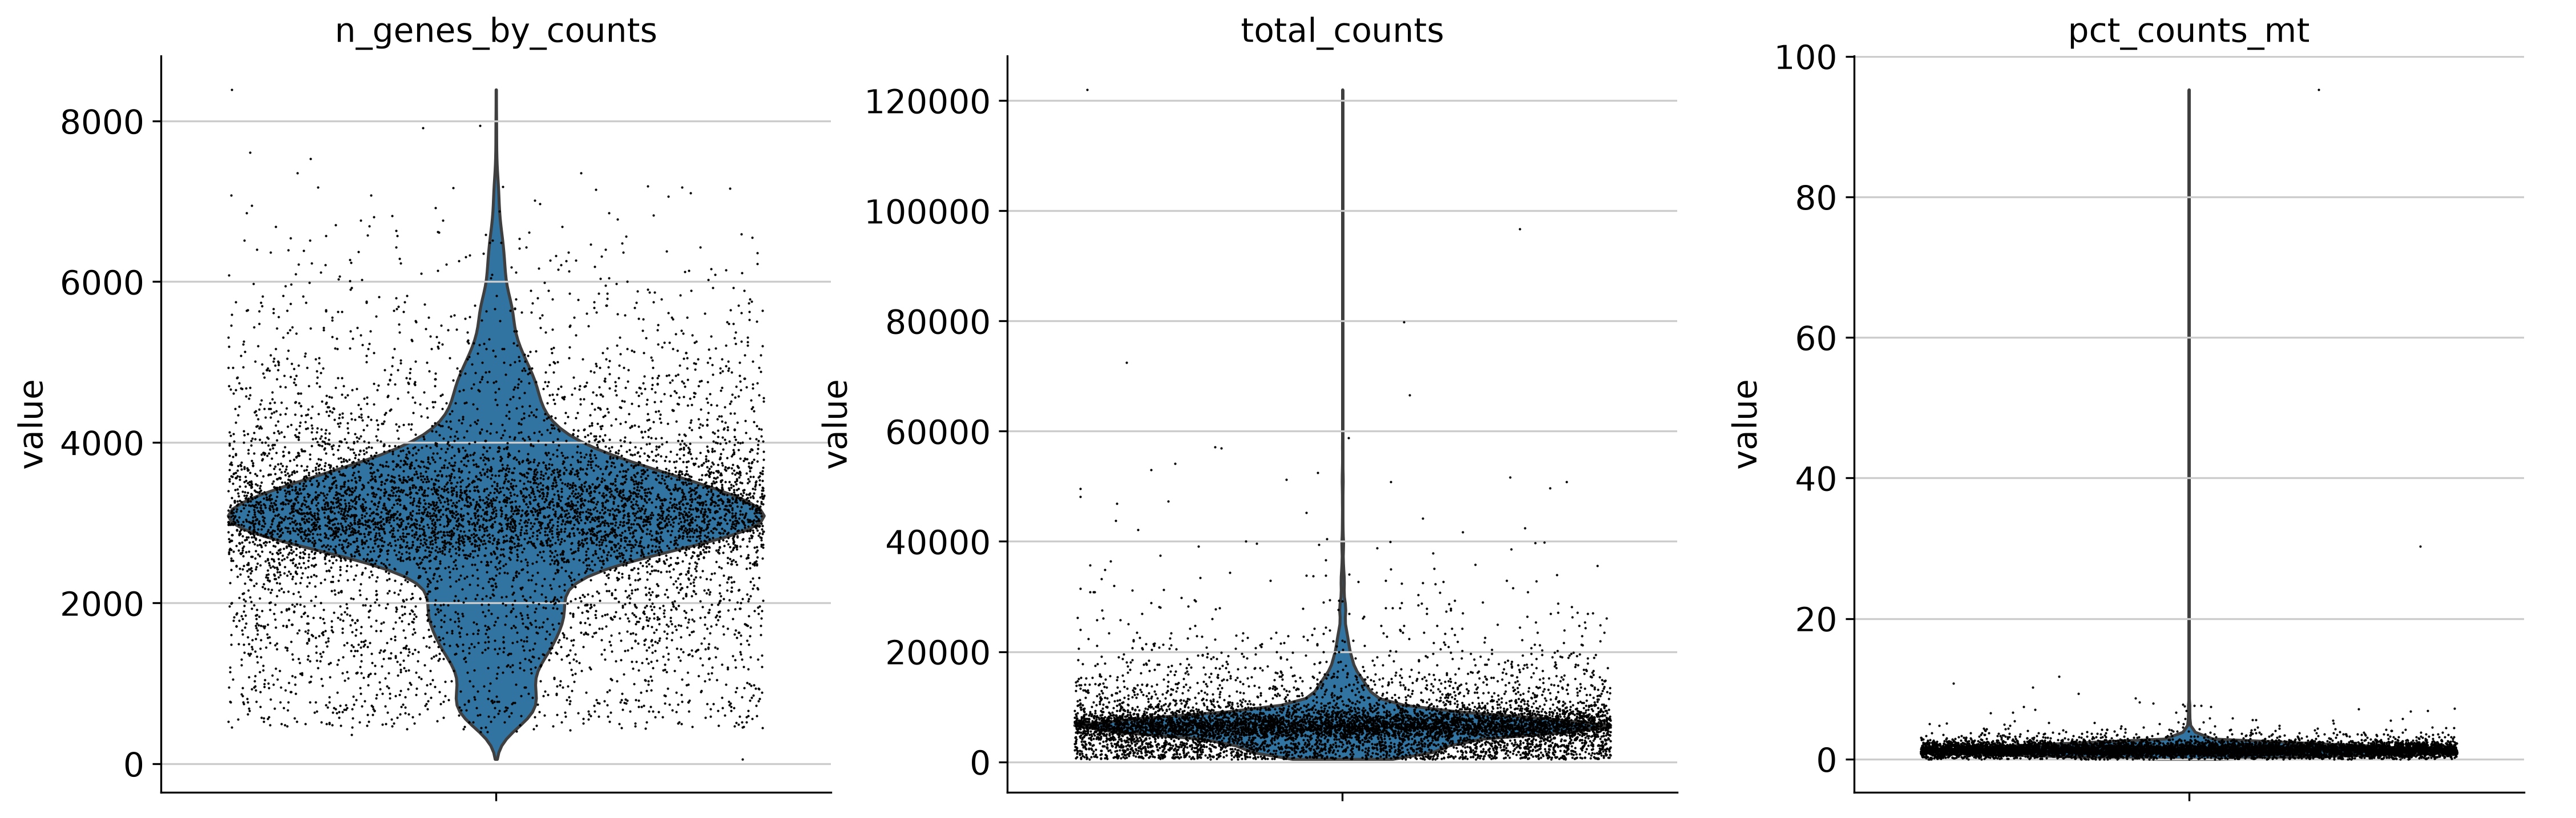

In [5]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4, 
    multi_panel=True,
)

In [6]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [7]:
# Doublet detection using scrublet
sc.external.pp.scrublet(adata)

In [8]:
# Remove doublets + other QC metrics
adata = adata[adata.obs['predicted_doublet'] == False]
sc.pp.filter_cells(adata, max_genes = 6000)
sc.pp.filter_cells(adata, max_counts = 35000)
adata = adata[adata.obs['pct_counts_mt'] < 5]

## Normalization, HVG, neighbors, PCA, UMAP

In [9]:
# Saving count data
adata.layers["counts"] = adata.X.copy()
# Normalization (Shifted logarithm)
sc.pp.normalize_total(adata, target_sum=None)
sc.pp.log1p(adata) 
# HVG
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
# PCA
sc.tl.pca(adata)
# Nearest neighbors analysis
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=20)
# UMAP
sc.tl.umap(adata)
# Clusterization
sc.tl.leiden(adata, resolution=0.5, key_added='leiden_0.5')

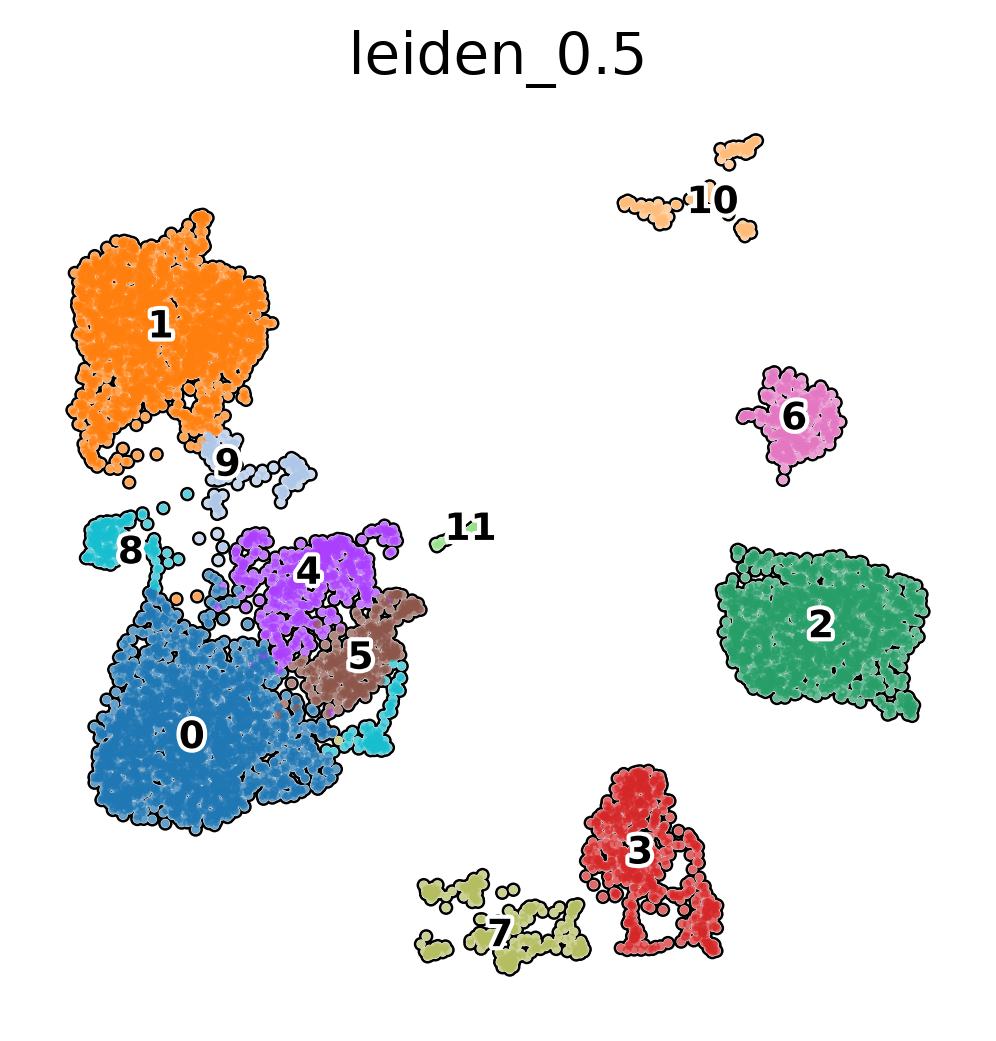

In [10]:
# Visualise clustering
sc.pl.umap(
    adata, 
    color = [
        'leiden_0.5'
    ],
    frameon = False,
    add_outline = True,
    legend_loc = 'on data',
    legend_fontsize = 9,
    legend_fontoutline = 2,
    save='_RNA_based_clustering.png'
)

In [11]:
adata.write_h5ad('mouse_RNA_based_clustering.h5ad')

## Observed ADT preprocessing

In [12]:
mu.prot.pp.clr(adata_adt)

In [13]:
adata_adt = adata_adt[adata.obs_names]
adata_adt.obsm['X_umap'] = adata.obsm['X_umap']

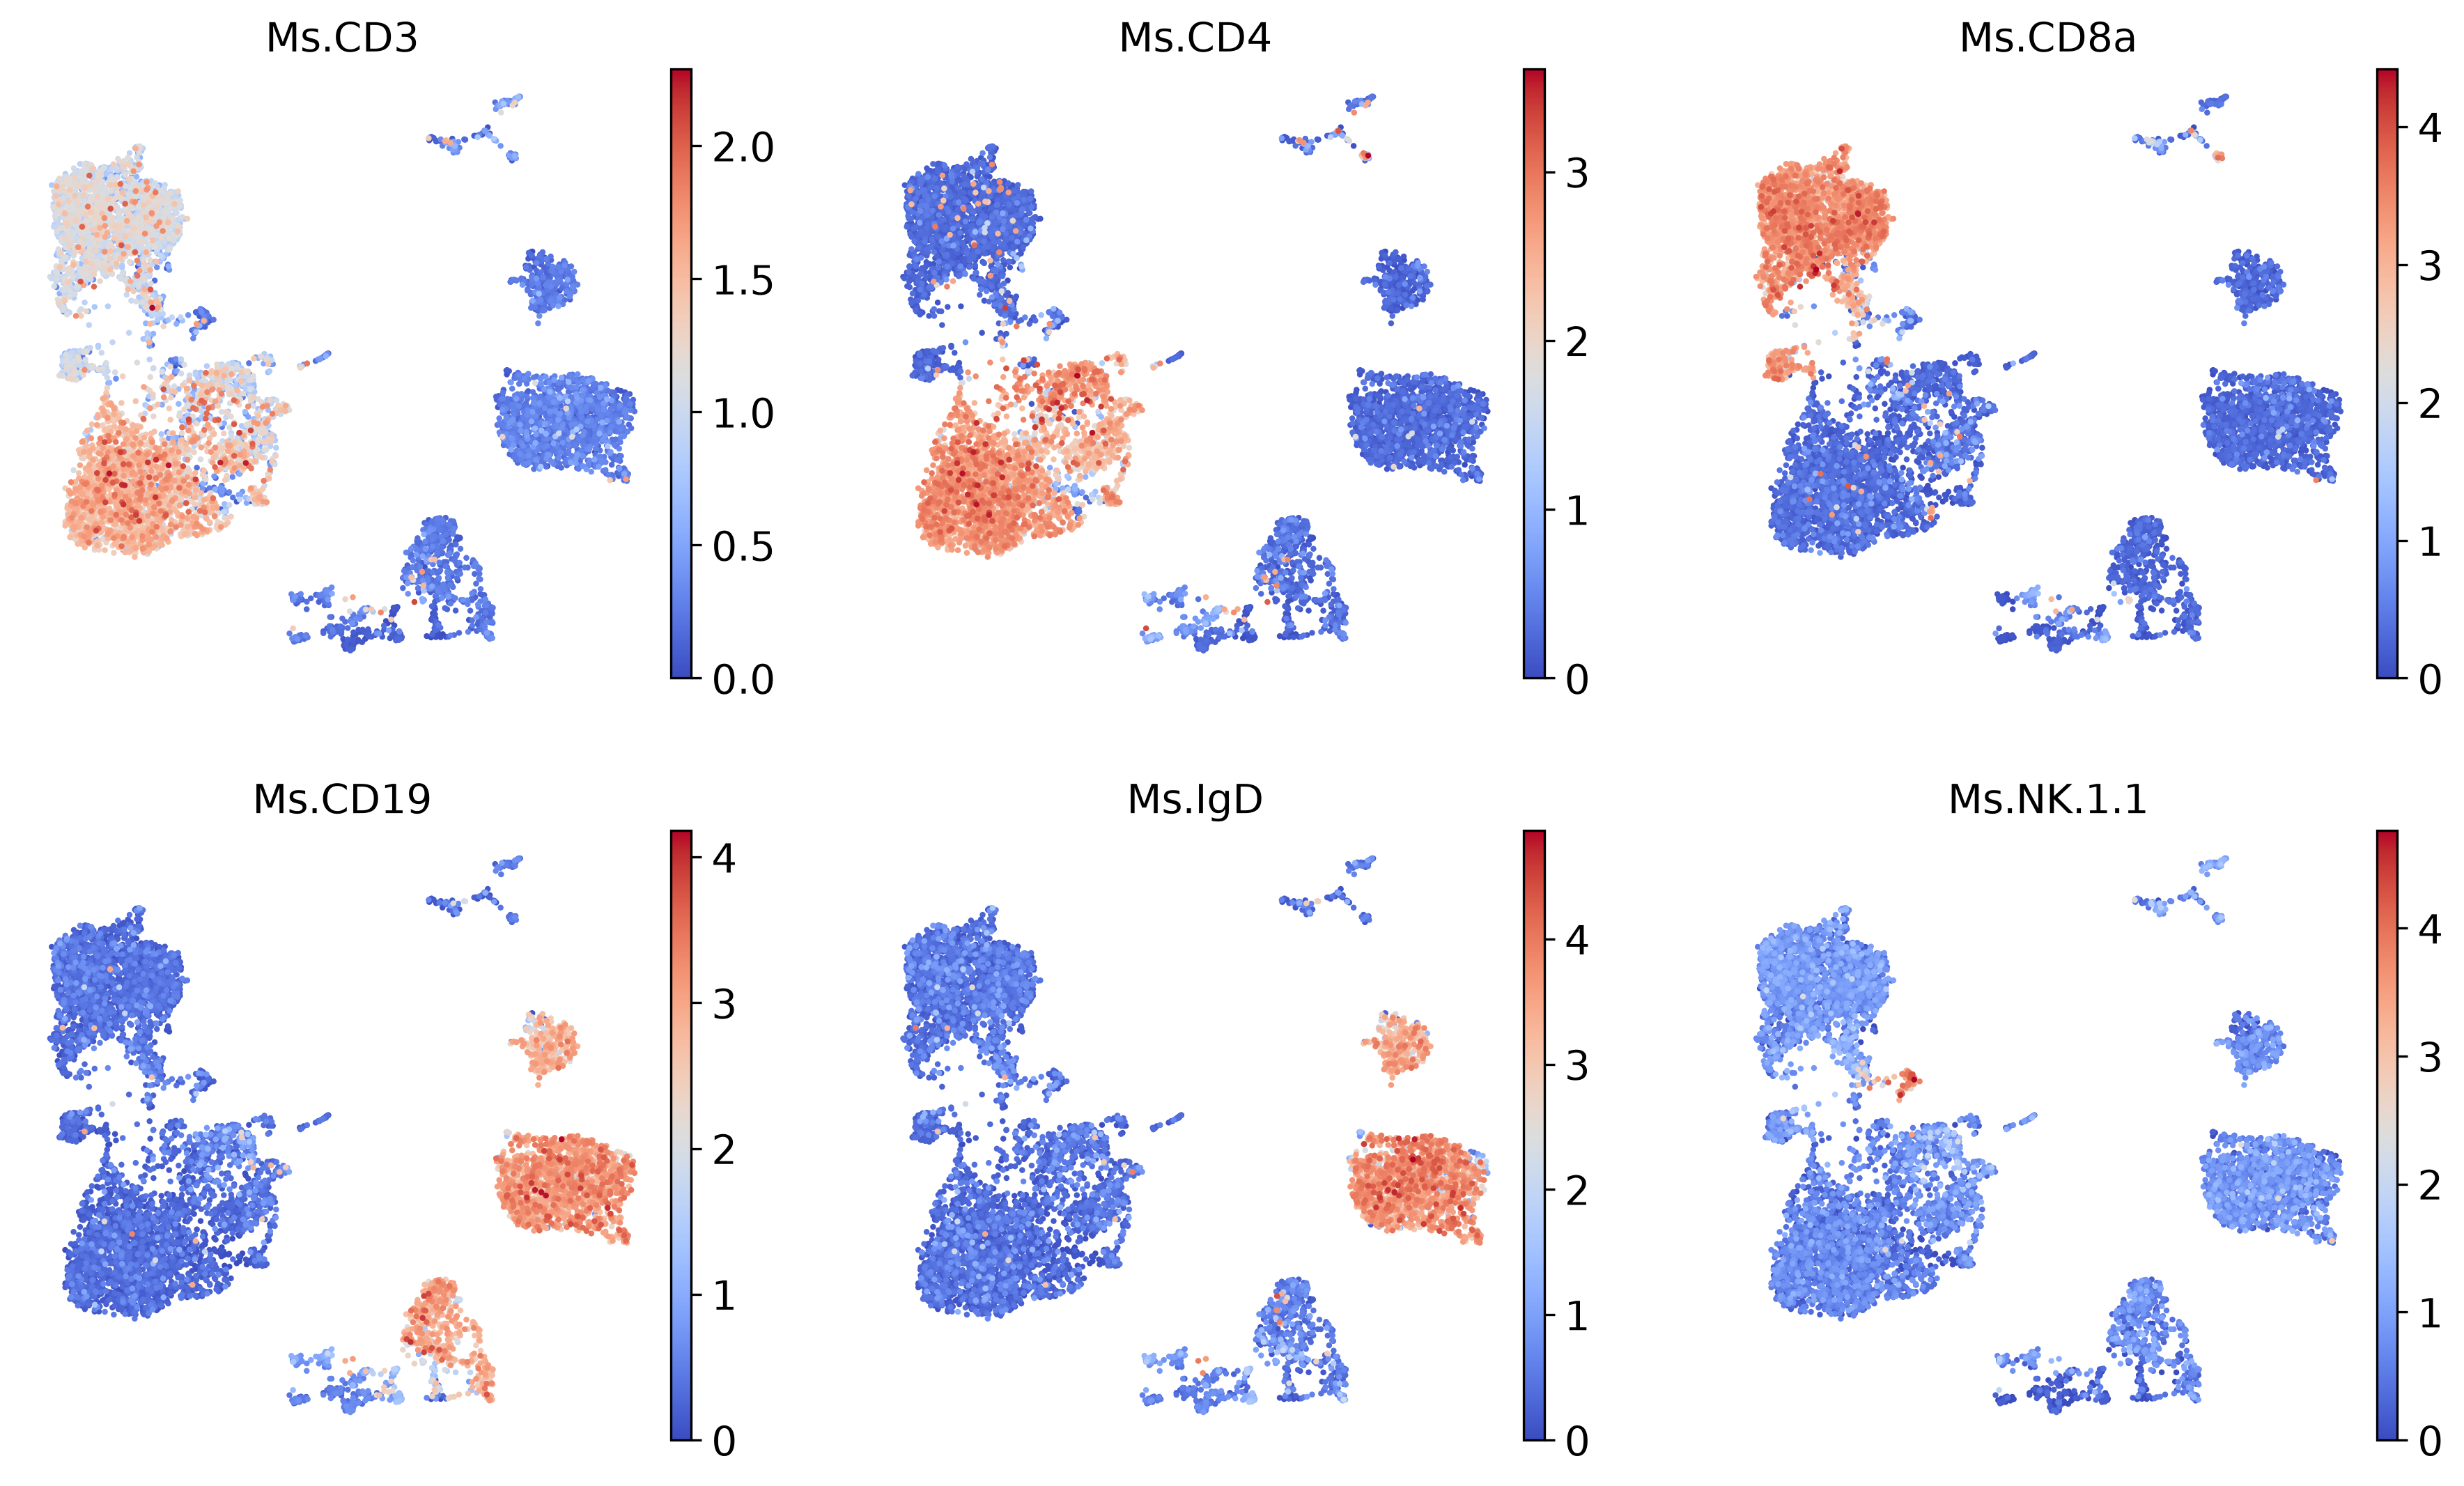

In [17]:
# Visualise observed proteins
sc.pl.umap(
    adata_adt, 
    color = [
        'Ms.CD3',
        'Ms.CD4',
        'Ms.CD8a',
        'Ms.CD19',
        'Ms.IgD',
        'Ms.NK.1.1'
    ],
    frameon = False,
    cmap = 'coolwarm',
    ncols = 3
)

## scParadise prediction (scEve)
To use the model trained on human cells, it is necessary to replace the names of mouse genes with their orthologs from the human genome. <br>
Orthologs - genes in different species that evolved from a common ancestor by speciation (Example: Acta2 in mouse, ACTA2 in human).

In [15]:
# Find orthologs of mouse genes in human genome
humanized_adata = translate(adata)

100%|███████████████████████████████████| 13167/13167 [00:15<00:00, 855.33it/s]


Found direct orthologs for 12219 genes.
Found multiple orthologs for 235 genes.
Found no orthologs for 442 genes.
Found no index in biomart for 271 genes.


100%|████████████████████████████████████████| 235/235 [00:05<00:00, 40.63it/s]
                                                                               

In [18]:
# Check matrix type and add it to raw
humanized_adata.X = sparse.csc_matrix(humanized_adata.X)
humanized_adata.raw = humanized_adata

In [19]:
# Available models for cell type annotation
scparadise.sceve.available_models(query = 'PBMC')

,Model name,Tissue/Organ,Species,Description,Suspension,RMSE,MAE,Number of Proteins
0,Human_PBMC_3p,blood,human,Peripheral blood mononuclear cells of healthy ...,cells,0.305,0.226,224
1,Human_PBMC_5p,blood,human,Peripheral blood mononuclear cells of healthy ...,cells,0.308,0.225,54


In [20]:
# Download model for modality prediction
scparadise.sceve.download_model(
    model_name = 'Human_PBMC_3p', 
    save_path = ''
)

In [21]:
# Predict surface proteins using trained model
adata_adt_pred = scparadise.sceve.predict(
    humanized_adata, 
    path_model = 'Human_PBMC_3p_scEve/',
    return_mdata = False
)

Feature prediction using the 2nd version of the scEve model
scEve model loaded from Human_PBMC_3p_scEve/
Feature alignment:
Model features: 2000
New data features: 13052
Matched features: 1162 (58.1%)


Predicting: 100%|██████████████████████████████| 29/29 [00:00<00:00, 60.83it/s]


In [22]:
# Add UMAP from RNA data
adata_adt_pred.obsm['X_umap'] = adata.obsm['X_umap']

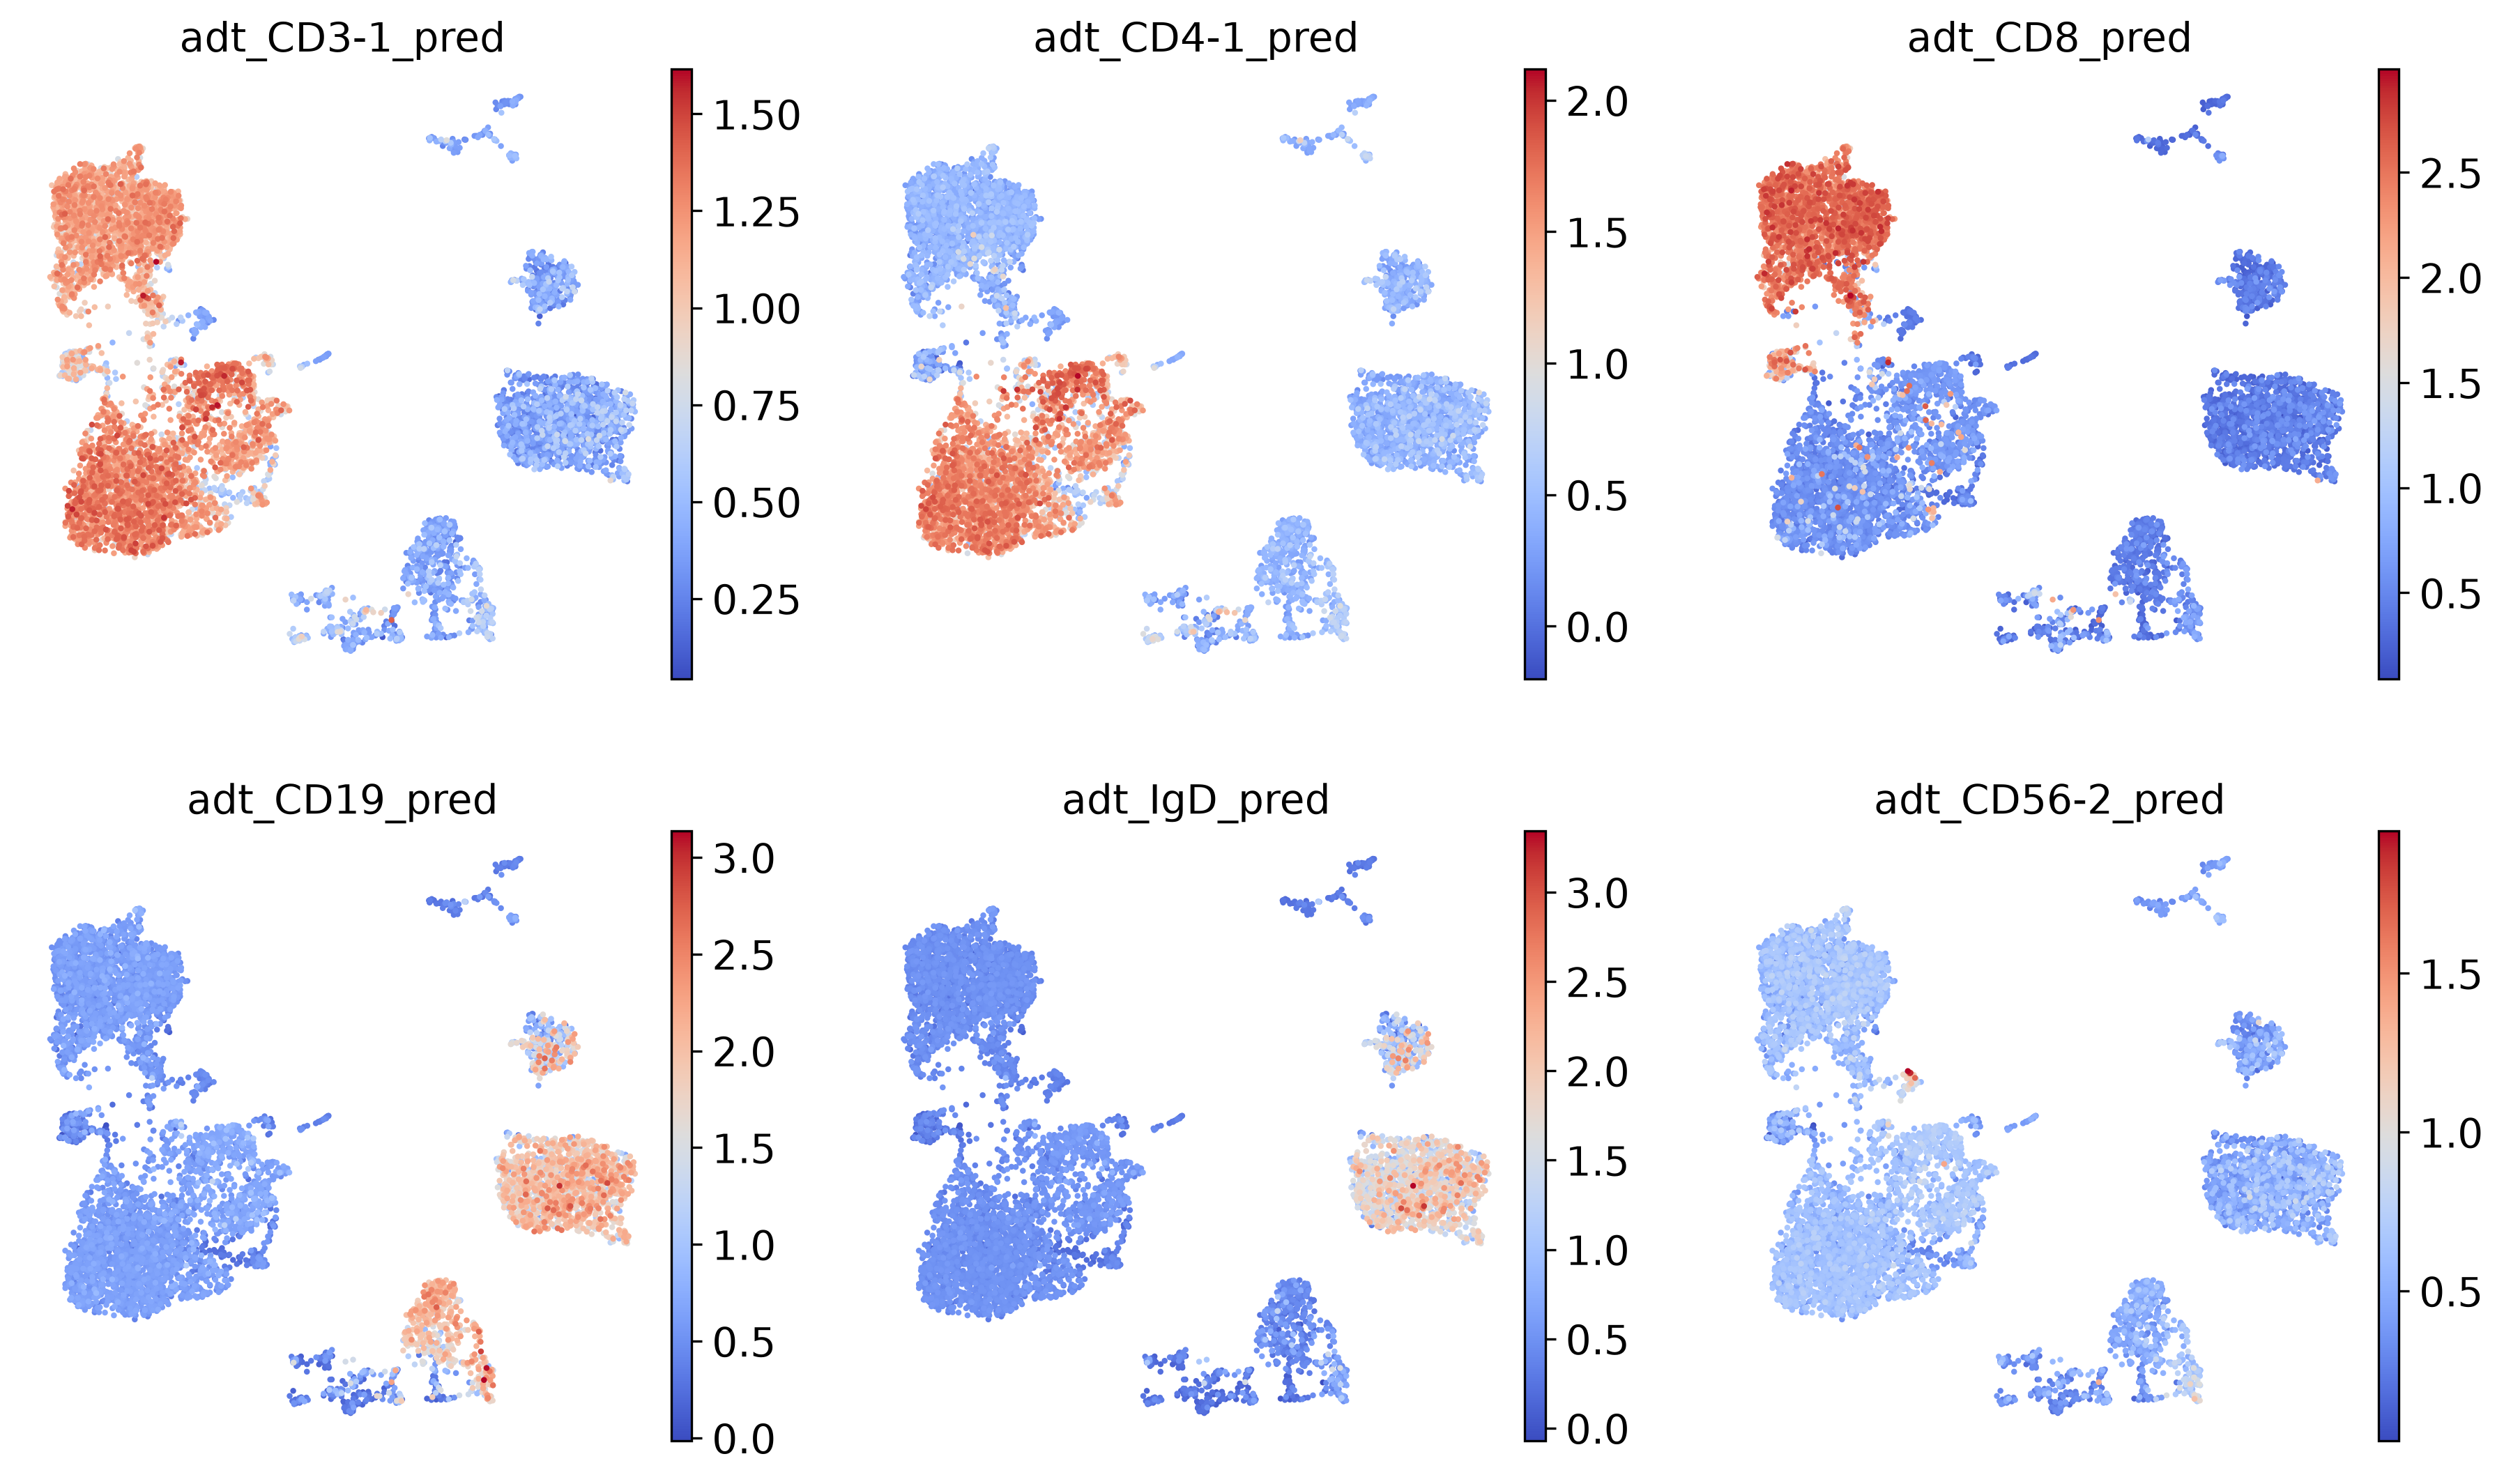

In [24]:
# Visualise imputed proteins
sc.pl.umap(
    adata_adt_pred, 
    color = [
        'adt_CD3-1_pred',
        'adt_CD4-1_pred',
        'adt_CD8_pred',
        'adt_CD19_pred',
        'adt_IgD_pred',
        'adt_CD56-2_pred'
    ],
    frameon = False,
    cmap = 'coolwarm',
    ncols = 3,
    save='_imputed_proteins.png'
)

## Check correlation between imputed and observed proteins

In [25]:
# Create lists with observed and imputed proteins
lst_prots = ['Ms.CD3', 'Ms.CD4', 'Ms.CD8a', 'Ms.CD19', 'Ms.IgD', 'Ms.NK.1.1']
lst_imp_prots = ['adt_CD3-1_pred', 'adt_CD4-1_pred', 'adt_CD8_pred', 'adt_CD19_pred', 'adt_IgD_pred', 'adt_CD56-2_pred']

In [26]:
# Calculate Pearson correlation coefficient for protein pairs
for i, j in zip(lst_prots, lst_imp_prots):
    pearson = scparadise.scnoah.pearson_coef(
        adata=adata_adt,
        adata_pred=adata_adt_pred,
        feature=i,
        feature_pred=j
    )
    coef = round(float(pearson['Pearson coefficient']), ndigits=4)
    print(f'Pearson coefficient for pair {i} - {j}: {coef}')

Pearson coefficient for pair Ms.CD3 - adt_CD3-1_pred: 0.81
Pearson coefficient for pair Ms.CD4 - adt_CD4-1_pred: 0.887
Pearson coefficient for pair Ms.CD8a - adt_CD8_pred: 0.945
Pearson coefficient for pair Ms.CD19 - adt_CD19_pred: 0.867
Pearson coefficient for pair Ms.IgD - adt_IgD_pred: 0.823
Pearson coefficient for pair Ms.NK.1.1 - adt_CD56-2_pred: 0.234


In [27]:
import session_info2
session_info2.session_info()

Package,Version
pandas,2.3.3
scanpy,1.11.5
scparadise,1.2.0
scipy,1.17.1
mousipy,0.1.7
muon,0.1.7
numpy,2.4.6
anndata,0.12.16
Component,Info
Python,"3.11.15 (main, Jun 11 2026, 15:20:16) [GCC 14.3.0]"
